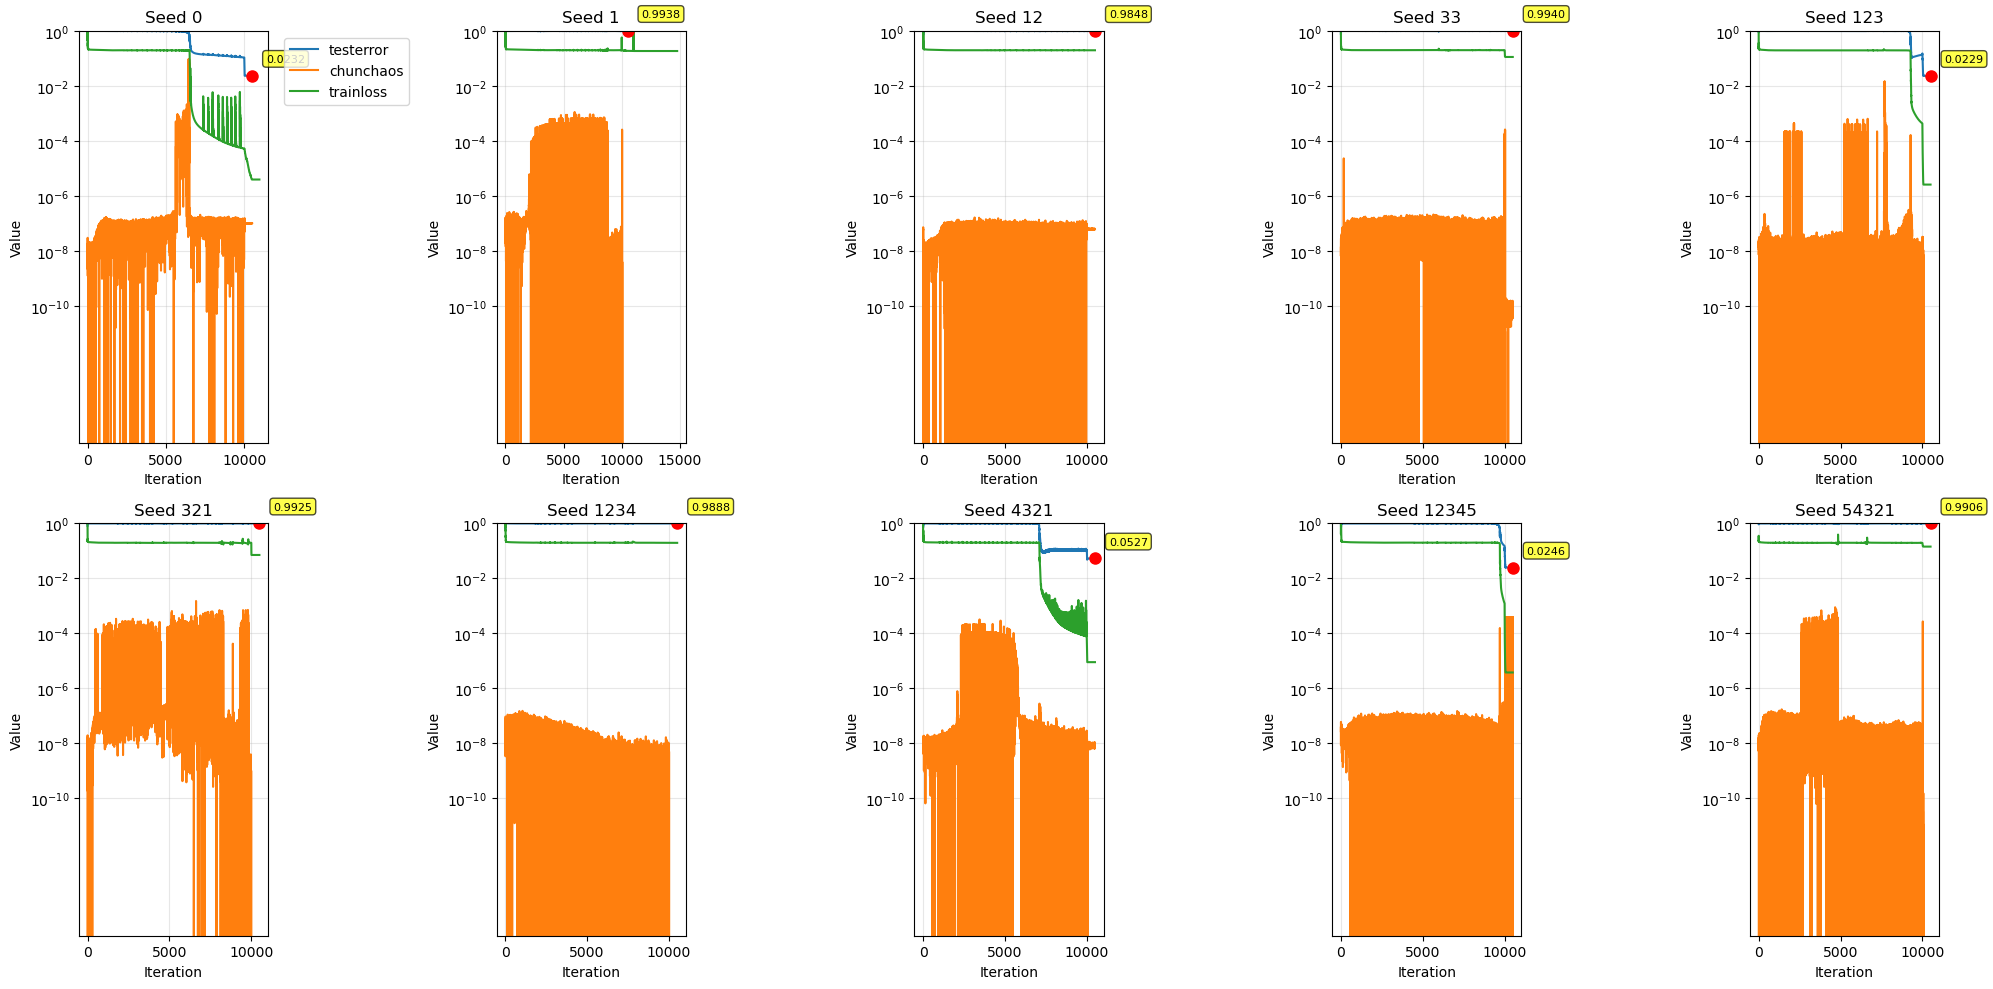

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import LogFormatterMathtext

# 种子列表
seeds = [0, 1, 12, 33, 123, 321, 1234, 4321, 12345, 54321]

# 创建子图布局（2行5列）
fig, axes = plt.subplots(2, 5, figsize=(20, 10))
axes = axes.flatten()  # 将二维数组展平为一维

# 为每个种子绘制图像
for idx, seed in enumerate(seeds):
    filename = f'DNN_data_{seed}.npz'
    
    try:
        # 加载数据
        data = np.load(filename)
        
        # 提取数据
        testerror = data['testerror']
        chunchaos = data['chunchaos']
        trainchaos = data['trainchaos']
        trainloss = data['trainloss']
        
        # 获取最后一个值
        last_testerror = testerror[-1]
        last_iteration = len(testerror) - 1
        
        # 在当前子图中绘制
        ax = axes[idx]
        ax.plot(testerror, label='testerror', linewidth=1.5)
        ax.plot(chunchaos, label='chunchaos', linewidth=1.5)
        ax.plot(trainloss, label='trainloss', linewidth=1.5)
        
        # 标注最后一个点
        ax.plot(last_iteration, last_testerror, 'ro', markersize=8)
        ax.annotate(f'{last_testerror:.4f}', 
                   xy=(last_iteration, last_testerror),
                   xytext=(10, 10),
                   textcoords='offset points',
                   fontsize=8,
                   bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow", alpha=0.7))
        
        ax.set_title(f'Seed {seed}')
        ax.set_xlabel('Iteration')
        ax.set_ylabel('Value')
        
        # 设置y轴为对数刻度，并固定范围
        ax.set_yscale('log')
        ax.set_ylim([1e-15, 1e0])  # 统一设置为10^-10到10^0
        
        # 设置y轴刻度
        ax.set_yticks([1e-10, 1e-8, 1e-6, 1e-4, 1e-2, 1e0])
        ax.set_yticklabels(['$10^{-10}$', '$10^{-8}$', '$10^{-6}$', '$10^{-4}$', '$10^{-2}$', '$10^{0}$'])
        
        ax.grid(True, alpha=0.3)
        
        # 只在第一个子图中添加图例
        if idx == 0:
            ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
            
    except FileNotFoundError:
        axes[idx].text(0.5, 0.5, f'File not found\nseed {seed}', 
                      ha='center', va='center')
        axes[idx].set_title(f'Seed {seed} (Missing)')
    except Exception as e:
        axes[idx].text(0.5, 0.5, f'Error: {e}', 
                      ha='center', va='center')
        axes[idx].set_title(f'Seed {seed} (Error)')

# 调整布局
plt.tight_layout()
plt.savefig('DNN_noAC_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

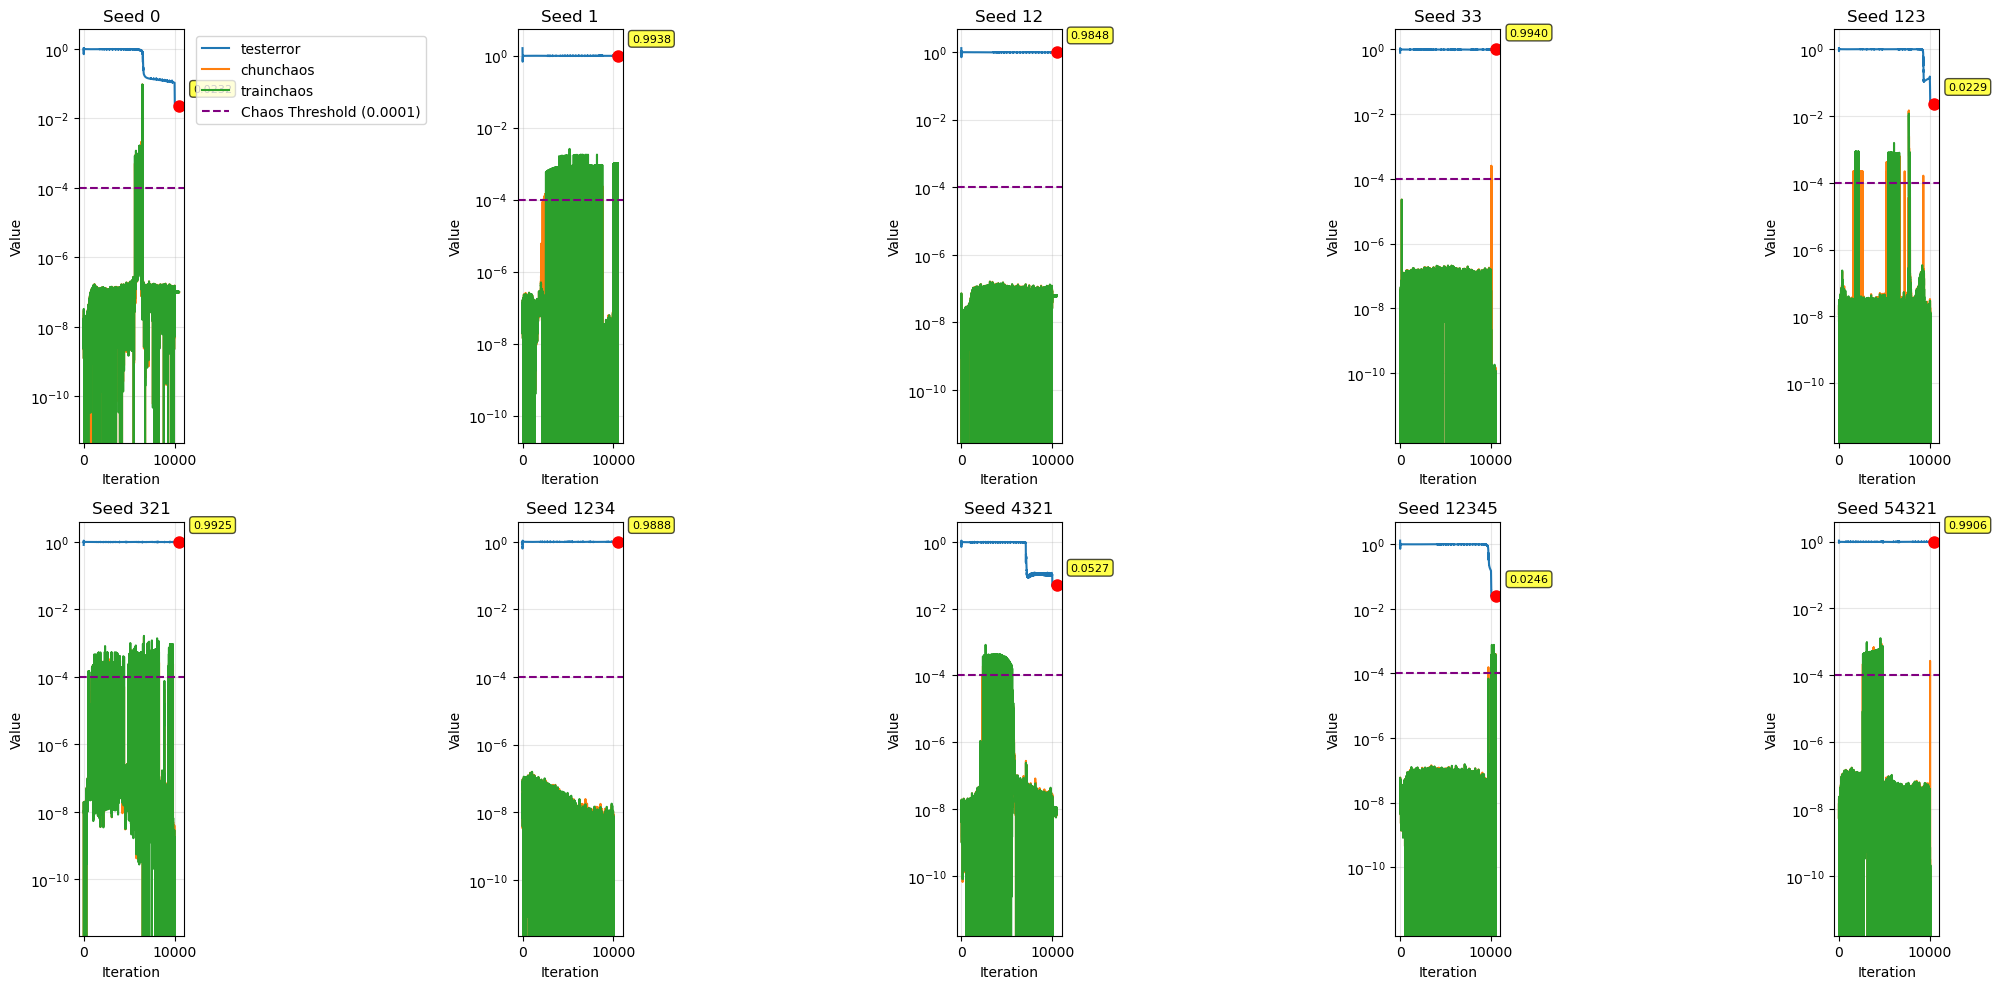


--- Chaos Analysis Results ---
Seed 0:
  Ordered Epochs: 9927
  Chaotic Epochs: 573
  Edge Crossings: 294
  Last Test Error: 2.3214e-02
--------------------
Seed 1:
  Ordered Epochs: 8939
  Chaotic Epochs: 1561
  Edge Crossings: 1948
  Last Test Error: 9.9375e-01
--------------------
Seed 12:
  Ordered Epochs: 10500
  Chaotic Epochs: 0
  Edge Crossings: 0
  Last Test Error: 9.8485e-01
--------------------
Seed 33:
  Ordered Epochs: 10492
  Chaotic Epochs: 8
  Edge Crossings: 8
  Last Test Error: 9.9402e-01
--------------------
Seed 123:
  Ordered Epochs: 10233
  Chaotic Epochs: 267
  Edge Crossings: 390
  Last Test Error: 2.2938e-02
--------------------
Seed 321:
  Ordered Epochs: 9225
  Chaotic Epochs: 1275
  Edge Crossings: 1850
  Last Test Error: 9.9250e-01
--------------------
Seed 1234:
  Ordered Epochs: 10500
  Chaotic Epochs: 0
  Edge Crossings: 0
  Last Test Error: 9.8875e-01
--------------------
Seed 4321:
  Ordered Epochs: 10224
  Chaotic Epochs: 276
  Edge Crossings: 418
  

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import LogFormatterMathtext

seeds = [0, 1, 12, 33, 123, 321, 1234, 4321, 12345, 54321]

# 定义混沌边缘阈值
CHAOS_THRESHOLD = 1e-4

# 存储每个seed的分析结果
analysis_results = []

fig, axes = plt.subplots(2, 5, figsize=(20, 10))
axes = axes.flatten()

for idx, seed in enumerate(seeds):
    filename = f'DNN_data_{seed}.npz'
    
    # 初始化统计变量
    ordered_epochs = 0
    chaotic_epochs = 0
    edge_crossings = 0
    
    try:
        data = np.load(filename)
        
        testerror = data['testerror']
        chunchaos = data['chunchaos']
        trainchaos = data['trainchaos']
        
        last_testerror = testerror[-1]
        last_iteration = len(testerror) - 1
        
        ax = axes[idx]
        ax.plot(testerror, label='testerror', linewidth=1.5)
        ax.plot(chunchaos, label='chunchaos', linewidth=1.5)
        ax.plot(trainchaos, label='trainchaos', linewidth=1.5)
        
        # 绘制混沌边缘
        ax.axhline(y=CHAOS_THRESHOLD, color='purple', linestyle='--', label=f'Chaos Threshold ({CHAOS_THRESHOLD})')
        
        ax.plot(last_iteration, last_testerror, 'ro', markersize=8)
        ax.annotate(f'{last_testerror:.4f}', 
                   xy=(last_iteration, last_testerror),
                   xytext=(10, 10),
                   textcoords='offset points',
                   fontsize=8,
                   bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow", alpha=0.7))
        
        ax.set_title(f'Seed {seed}')
        ax.set_xlabel('Iteration')
        ax.set_ylabel('Value')
        
        ax.set_yscale('log')
        ax.set_yticks([1e-10, 1e-8, 1e-6, 1e-4, 1e-2, 1e0])
        ax.set_yticklabels(['$10^{-10}$', '$10^{-8}$', '$10^{-6}$', '$10^{-4}$', '$10^{-2}$', '$10^{0}$'])
        
        ax.grid(True, alpha=0.3)
        
        if idx == 0:
            ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

        # ----------- 新增分析部分 -----------
        previous_state = None # 'ordered' or 'chaotic'
        
        for i, chaos_value in enumerate(chunchaos):
            if chaos_value < CHAOS_THRESHOLD:
                current_state = 'ordered'
                ordered_epochs += 1
            else:
                current_state = 'chaotic'
                chaotic_epochs += 1
            
            # 统计边缘穿过次数
            if previous_state is not None and current_state != previous_state:
                edge_crossings += 1
            
            previous_state = current_state
        
        analysis_results.append({
            'seed': seed,
            'ordered_epochs': ordered_epochs,
            'chaotic_epochs': chaotic_epochs,
            'edge_crossings': edge_crossings,
            'last_testerror': last_testerror # 添加这行
        })
        # -----------------------------------
        
    except FileNotFoundError:
        axes[idx].text(0.5, 0.5, f'File not found\nseed {seed}', 
                      ha='center', va='center')
        axes[idx].set_title(f'Seed {seed} (Missing)')
        analysis_results.append({'seed': seed, 'error': 'File Not Found'})
    except Exception as e:
        axes[idx].text(0.5, 0.5, f'Error: {e}', 
                      ha='center', va='center')
        axes[idx].set_title(f'Seed {seed} (Error)')
        analysis_results.append({'seed': seed, 'error': str(e)})

plt.tight_layout()
plt.savefig('DNN_noAC_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# 打印分析结果
print("\n--- Chaos Analysis Results ---")
for result in analysis_results:
    if 'error' in result:
        print(f"Seed {result['seed']}: Error - {result['error']}")
    else:
        print(f"Seed {result['seed']}:")
        print(f"  Ordered Epochs: {result['ordered_epochs']}")
        print(f"  Chaotic Epochs: {result['chaotic_epochs']}")
        print(f"  Edge Crossings: {result['edge_crossings']}")
        print(f"  Last Test Error: {result['last_testerror']:.4e}") # 添加这行
        print("-" * 20)

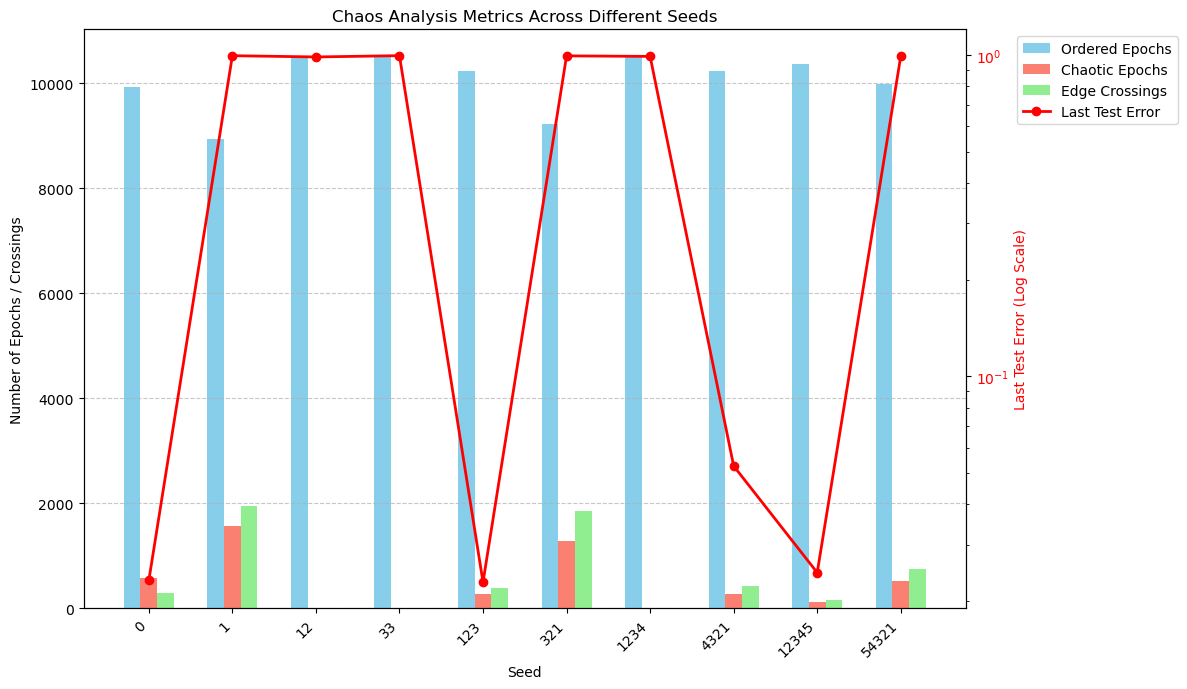

In [27]:
# --- 以下是新增的代码，用于绘制分析结果在一张图上 ---

# 过滤掉有错误的seed，只保留成功分析的数据
filtered_results = [res for res in analysis_results if 'error' not in res]

if not filtered_results:
    print("没有可用的分析结果数据进行绘图。")
else:
    # 提取用于绘图的数据
    seeds_for_plot = [str(res['seed']) for res in filtered_results] # 将seed转为字符串作为x轴标签
    ordered_epochs_data = [res['ordered_epochs'] for res in filtered_results]
    chaotic_epochs_data = [res['chaotic_epochs'] for res in filtered_results]
    edge_crossings_data = [res['edge_crossings'] for res in filtered_results]
    last_testerror_data = [res['last_testerror'] for res in filtered_results]

    # 创建一个新的图和主Y轴
    fig_single, ax1 = plt.subplots(figsize=(12, 7))

    # 绘制有序 Epochs, 混沌 Epochs, 边缘穿过次数（使用主Y轴）
    # 可以使用堆叠柱状图或并列柱状图，这里以并列柱状图为例
    x = np.arange(len(seeds_for_plot)) # X轴位置
    width = 0.2 # 柱子的宽度

    rects1 = ax1.bar(x - width, ordered_epochs_data, width, label='Ordered Epochs', color='skyblue')
    rects2 = ax1.bar(x, chaotic_epochs_data, width, label='Chaotic Epochs', color='salmon')
    rects3 = ax1.bar(x + width, edge_crossings_data, width, label='Edge Crossings', color='lightgreen')

    ax1.set_xlabel('Seed')
    ax1.set_ylabel('Number of Epochs / Crossings', color='black')
    ax1.set_title('Chaos Analysis Metrics Across Different Seeds')
    ax1.set_xticks(x)
    ax1.set_xticklabels(seeds_for_plot, rotation=45, ha='right')
    ax1.tick_params(axis='y', labelcolor='black')
    ax1.grid(axis='y', linestyle='--', alpha=0.7)

    # 创建第二个Y轴，共享X轴
    ax2 = ax1.twinx() 
    # 绘制 Last Test Error（使用第二个Y轴）
    line1 = ax2.plot(x, last_testerror_data, marker='o', linestyle='-', color='red', label='Last Test Error', linewidth=2)
    ax2.set_ylabel('Last Test Error (Log Scale)', color='red')
    ax2.tick_params(axis='y', labelcolor='red')
    ax2.set_yscale('log') # Test Error 通常使用对数刻度

    # 合并图例
    bars = [rects1, rects2, rects3]
    labels = [b.get_label() for b in bars]
    lines = line1
    labels.extend([l.get_label() for l in lines])
    
    ax1.legend(bars + lines, labels, loc='upper left', bbox_to_anchor=(1.05, 1))

    plt.tight_layout() # 自动调整布局，防止标签重叠
    plt.savefig('Single_Plot_Chaos_Analysis_Summary.png', dpi=300, bbox_inches='tight')
    plt.show()

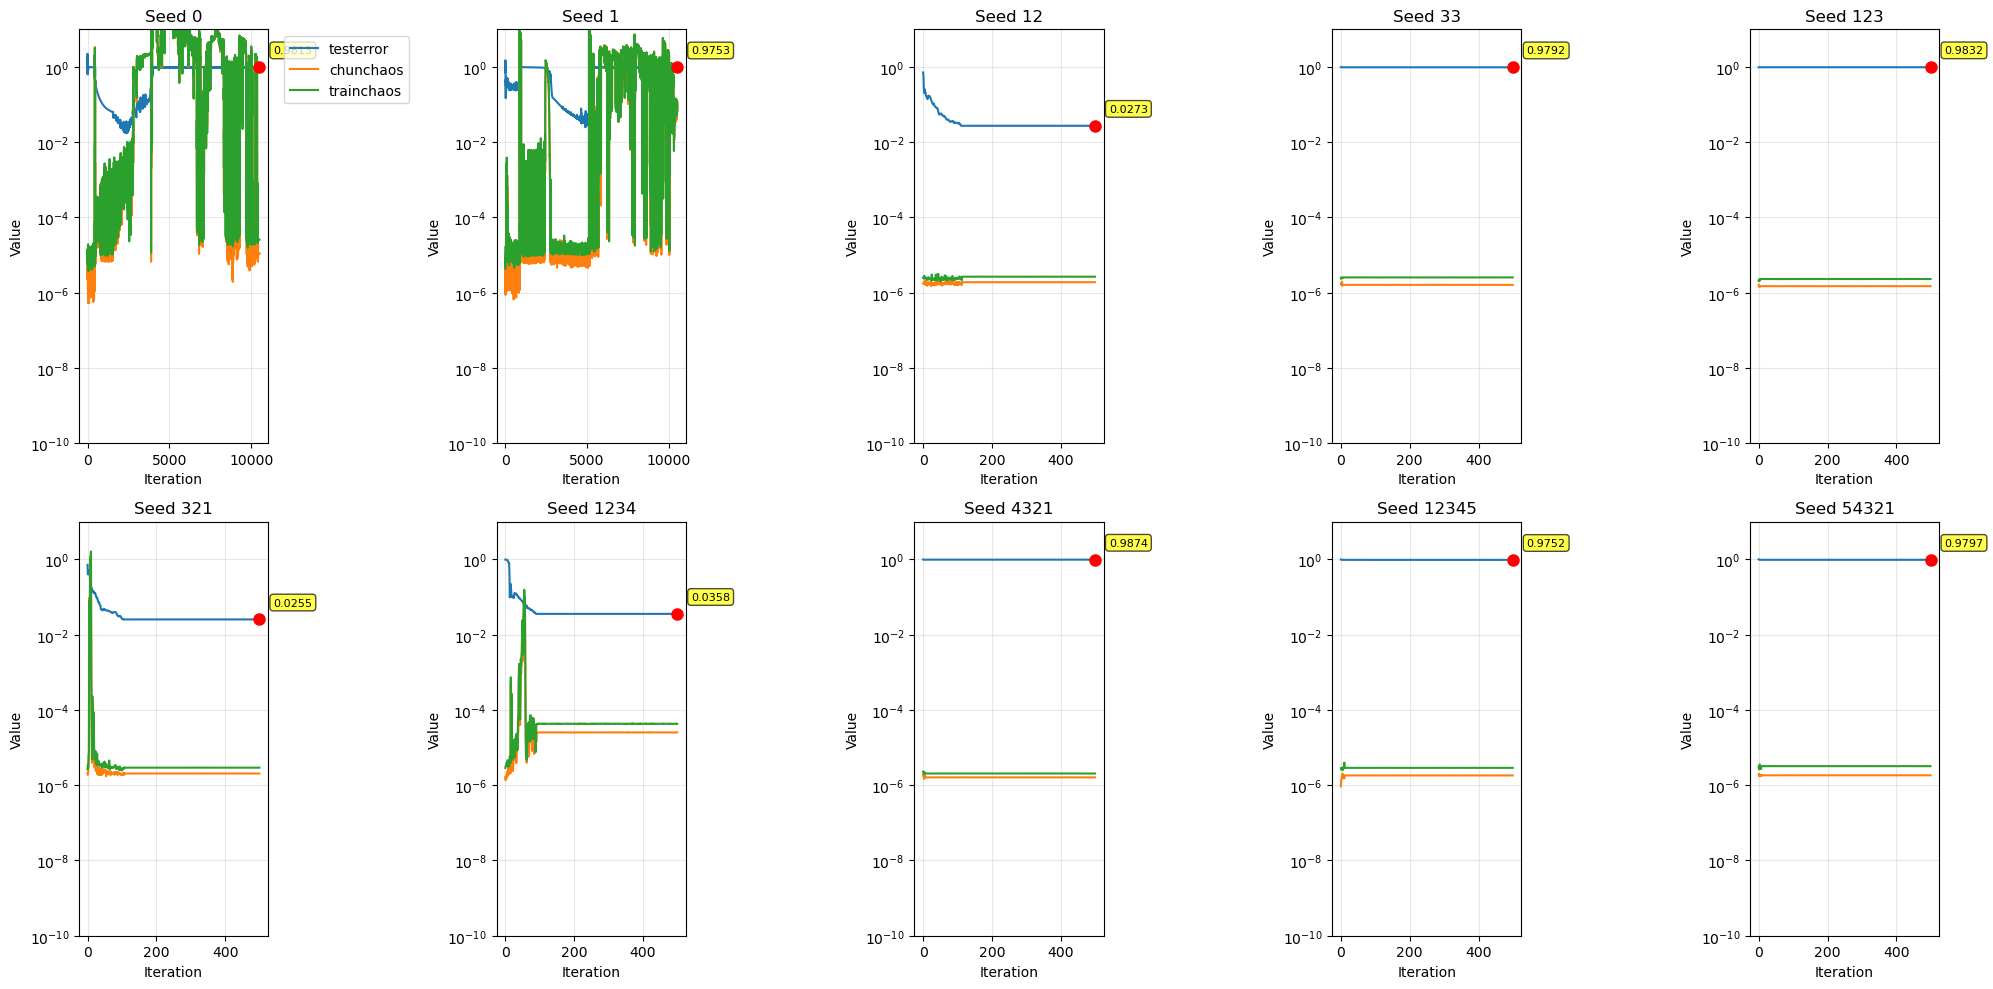

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import LogFormatterMathtext

# 种子列表
seeds = [0, 1, 12, 33, 123, 321, 1234, 4321, 12345, 54321]

# 创建子图布局（2行5列）
fig, axes = plt.subplots(2, 5, figsize=(20, 10))
axes = axes.flatten()  # 将二维数组展平为一维

# 为每个种子绘制图像
for idx, seed in enumerate(seeds):
    filename = f'transformer_data_{seed}.npz'
    
    try:
        # 加载数据
        data = np.load(filename)
        
        # 提取数据
        testerror = data['testerror']
        chunchaos = data['chunchaos']
        trainchaos = data['trainchaos']
        
        # 获取最后一个值
        last_testerror = testerror[-1]
        last_iteration = len(testerror) - 1
        
        # 在当前子图中绘制
        ax = axes[idx]
        ax.plot(testerror, label='testerror', linewidth=1.5)
        ax.plot(chunchaos, label='chunchaos', linewidth=1.5)
        ax.plot(trainchaos,label='trainchaos',linewidth=1.5)
        
        # 标注最后一个点
        ax.plot(last_iteration, last_testerror, 'ro', markersize=8)
        ax.annotate(f'{last_testerror:.4f}', 
                   xy=(last_iteration, last_testerror),
                   xytext=(10, 10),
                   textcoords='offset points',
                   fontsize=8,
                   bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow", alpha=0.7))
        
        ax.set_title(f'Seed {seed}')
        ax.set_xlabel('Iteration')
        ax.set_ylabel('Value')
        
        # 设置y轴为对数刻度，并固定范围
        ax.set_yscale('log')
        ax.set_ylim([1e-10, 1e1])  # 统一设置为10^-10到10^0
        
        # 设置y轴刻度
        ax.set_yticks([1e-10, 1e-8, 1e-6, 1e-4, 1e-2, 1e0])
        ax.set_yticklabels(['$10^{-10}$', '$10^{-8}$', '$10^{-6}$', '$10^{-4}$', '$10^{-2}$', '$10^{0}$'])
        
        ax.grid(True, alpha=0.3)
        
        # 只在第一个子图中添加图例
        if idx == 0:
            ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
            
    except FileNotFoundError:
        axes[idx].text(0.5, 0.5, f'File not found\nseed {seed}', 
                      ha='center', va='center')
        axes[idx].set_title(f'Seed {seed} (Missing)')
    except Exception as e:
        axes[idx].text(0.5, 0.5, f'Error: {e}', 
                      ha='center', va='center')
        axes[idx].set_title(f'Seed {seed} (Error)')

# 调整布局
plt.tight_layout()
plt.savefig('transformer_noAC_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

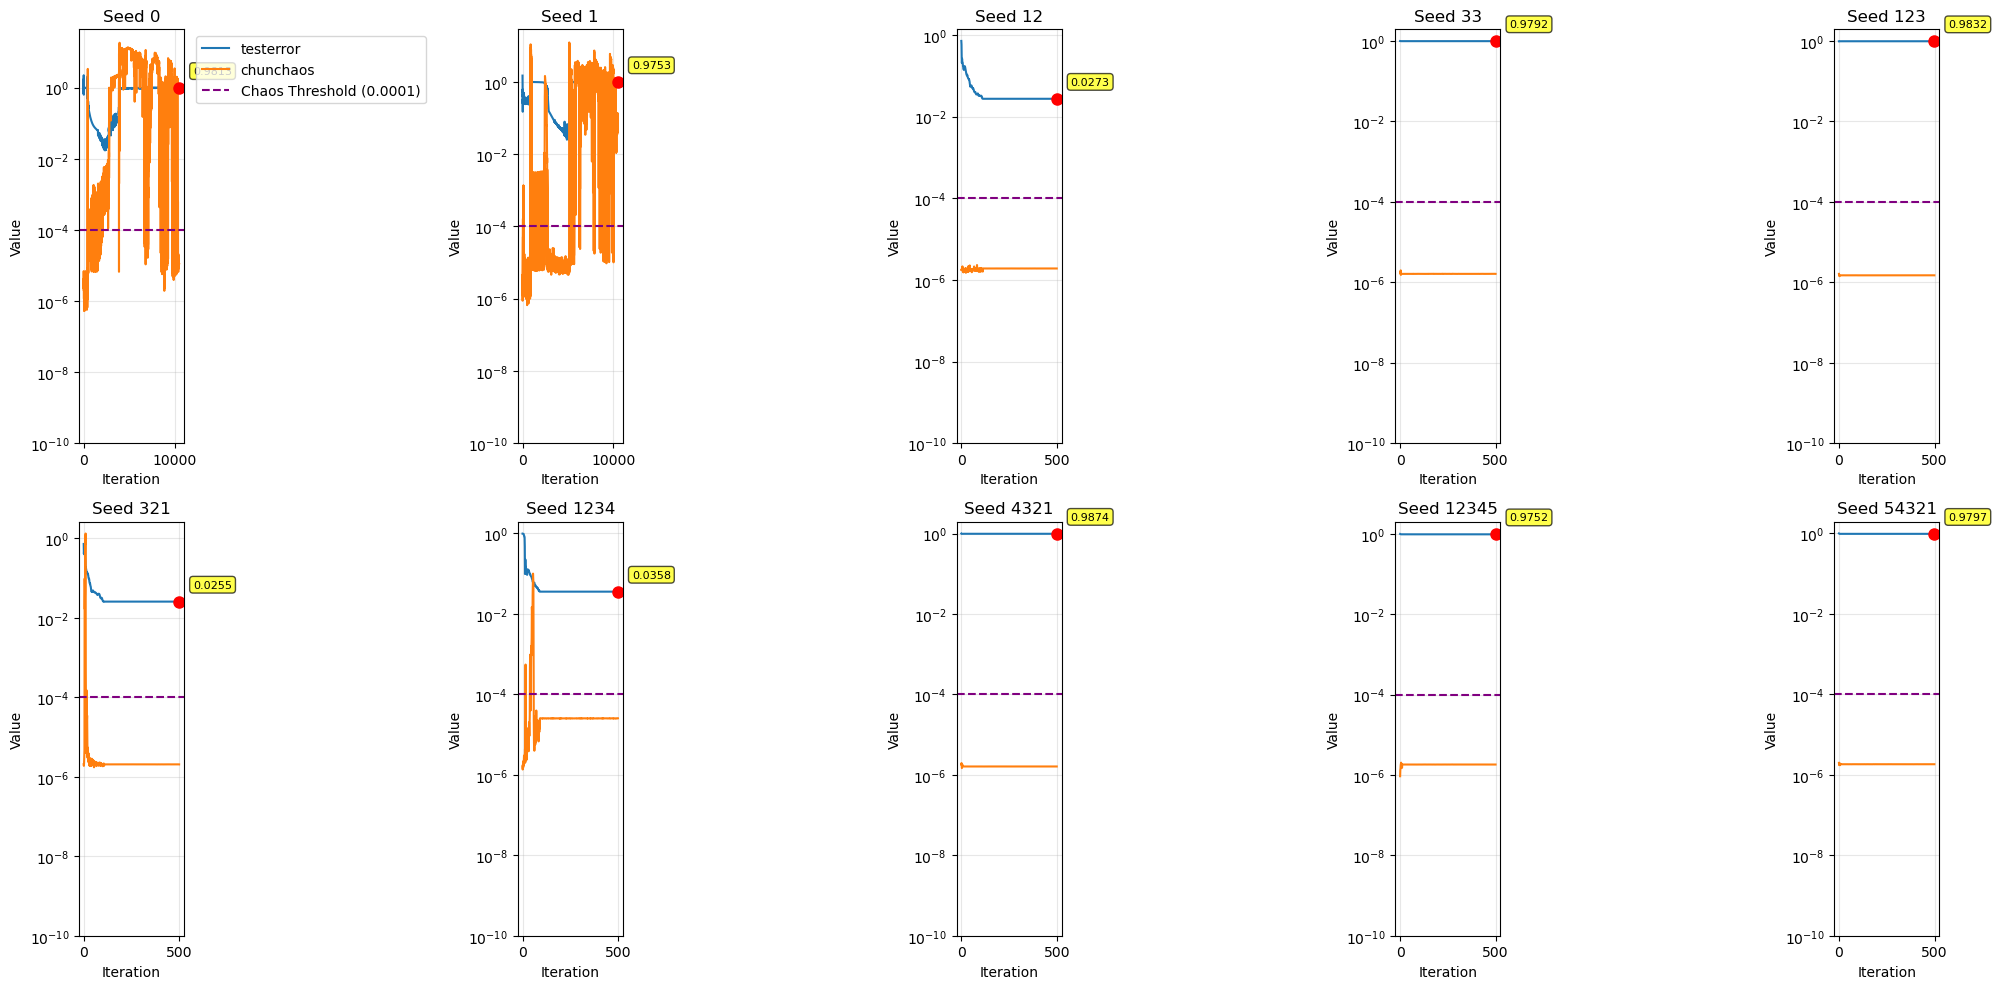


--- Chaos Analysis Results ---
Seed 0:
  Ordered Epochs: 1735
  Chaotic Epochs: 8765
  Edge Crossings: 836
  Last Test Error: 9.8135e-01
--------------------
Seed 1:
  Ordered Epochs: 4335
  Chaotic Epochs: 6165
  Edge Crossings: 839
  Last Test Error: 9.7534e-01
--------------------
Seed 12:
  Ordered Epochs: 500
  Chaotic Epochs: 0
  Edge Crossings: 0
  Last Test Error: 2.7330e-02
--------------------
Seed 33:
  Ordered Epochs: 500
  Chaotic Epochs: 0
  Edge Crossings: 0
  Last Test Error: 9.7916e-01
--------------------
Seed 123:
  Ordered Epochs: 500
  Chaotic Epochs: 0
  Edge Crossings: 0
  Last Test Error: 9.8320e-01
--------------------
Seed 321:
  Ordered Epochs: 490
  Chaotic Epochs: 10
  Edge Crossings: 4
  Last Test Error: 2.5485e-02
--------------------
Seed 1234:
  Ordered Epochs: 481
  Chaotic Epochs: 19
  Edge Crossings: 6
  Last Test Error: 3.5802e-02
--------------------
Seed 4321:
  Ordered Epochs: 500
  Chaotic Epochs: 0
  Edge Crossings: 0
  Last Test Error: 9.8740

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import LogFormatterMathtext

seeds = [0, 1, 12, 33, 123, 321, 1234, 4321, 12345, 54321]

# 定义混沌边缘阈值
CHAOS_THRESHOLD = 1e-4

# 存储每个seed的分析结果
analysis_results = []

fig, axes = plt.subplots(2, 5, figsize=(20, 10))
axes = axes.flatten()

for idx, seed in enumerate(seeds):
    filename = f'transformer_data_{seed}.npz'
    
    # 初始化统计变量
    ordered_epochs = 0
    chaotic_epochs = 0
    edge_crossings = 0
    
    try:
        data = np.load(filename)
        
        testerror = data['testerror']
        chunchaos = data['chunchaos']
        # trainchaos = data['trainchaos']
        
        last_testerror = testerror[-1]
        last_iteration = len(testerror) - 1
        
        ax = axes[idx]
        ax.plot(testerror, label='testerror', linewidth=1.5)
        ax.plot(chunchaos, label='chunchaos', linewidth=1.5)
        # ax.plot(trainchaos, label='trainchaos', linewidth=1.5)
        
        # 绘制混沌边缘
        ax.axhline(y=CHAOS_THRESHOLD, color='purple', linestyle='--', label=f'Chaos Threshold ({CHAOS_THRESHOLD})')
        
        ax.plot(last_iteration, last_testerror, 'ro', markersize=8)
        ax.annotate(f'{last_testerror:.4f}', 
                   xy=(last_iteration, last_testerror),
                   xytext=(10, 10),
                   textcoords='offset points',
                   fontsize=8,
                   bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow", alpha=0.7))
        
        ax.set_title(f'Seed {seed}')
        ax.set_xlabel('Iteration')
        ax.set_ylabel('Value')
        
        ax.set_yscale('log')
        ax.set_yticks([1e-10, 1e-8, 1e-6, 1e-4, 1e-2, 1e0])
        ax.set_yticklabels(['$10^{-10}$', '$10^{-8}$', '$10^{-6}$', '$10^{-4}$', '$10^{-2}$', '$10^{0}$'])
        
        ax.grid(True, alpha=0.3)
        
        if idx == 0:
            ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

        # ----------- 新增分析部分 -----------
        previous_state = None # 'ordered' or 'chaotic'
        
        for i, chaos_value in enumerate(chunchaos):
            if chaos_value < CHAOS_THRESHOLD:
                current_state = 'ordered'
                ordered_epochs += 1
            else:
                current_state = 'chaotic'
                chaotic_epochs += 1
            
            # 统计边缘穿过次数
            if previous_state is not None and current_state != previous_state:
                edge_crossings += 1
            
            previous_state = current_state
        
        analysis_results.append({
            'seed': seed,
            'ordered_epochs': ordered_epochs,
            'chaotic_epochs': chaotic_epochs,
            'edge_crossings': edge_crossings,
            'last_testerror': last_testerror # 添加这行
        })
        # -----------------------------------
        
    except FileNotFoundError:
        axes[idx].text(0.5, 0.5, f'File not found\nseed {seed}', 
                      ha='center', va='center')
        axes[idx].set_title(f'Seed {seed} (Missing)')
        analysis_results.append({'seed': seed, 'error': 'File Not Found'})
    except Exception as e:
        axes[idx].text(0.5, 0.5, f'Error: {e}', 
                      ha='center', va='center')
        axes[idx].set_title(f'Seed {seed} (Error)')
        analysis_results.append({'seed': seed, 'error': str(e)})

plt.tight_layout()
plt.savefig('transformer_noAC_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# 打印分析结果
print("\n--- Chaos Analysis Results ---")
for result in analysis_results:
    if 'error' in result:
        print(f"Seed {result['seed']}: Error - {result['error']}")
    else:
        print(f"Seed {result['seed']}:")
        print(f"  Ordered Epochs: {result['ordered_epochs']}")
        print(f"  Chaotic Epochs: {result['chaotic_epochs']}")
        print(f"  Edge Crossings: {result['edge_crossings']}")
        print(f"  Last Test Error: {result['last_testerror']:.4e}") # 添加这行
        print("-" * 20)

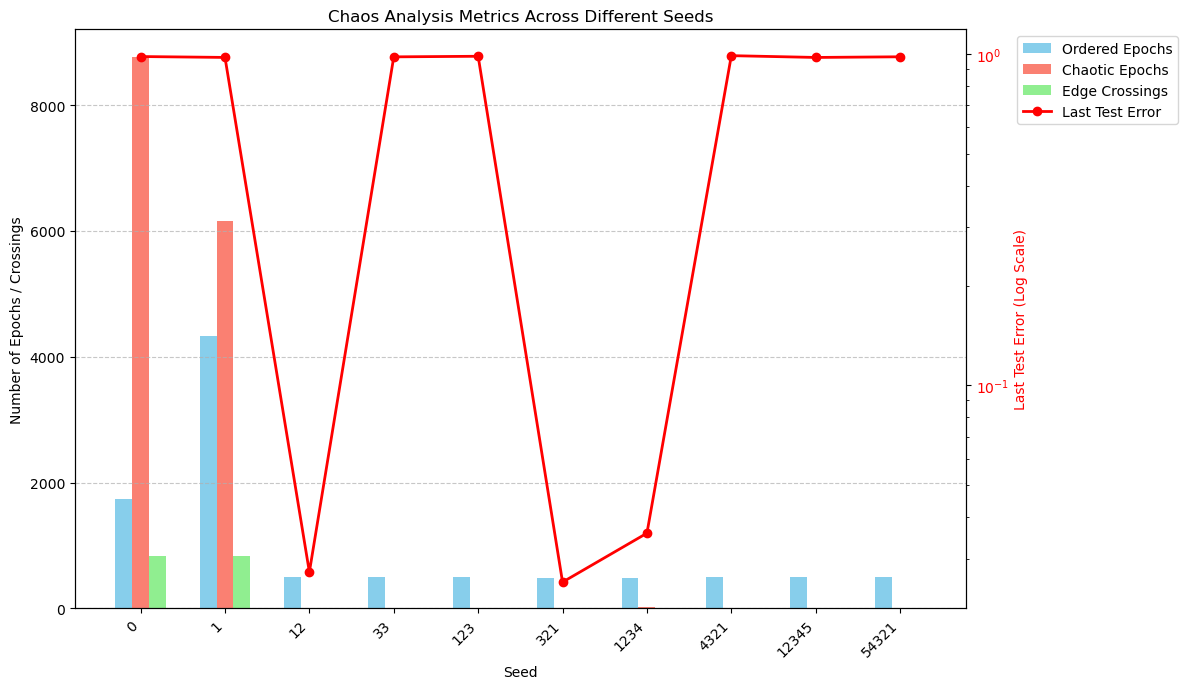

In [30]:
# --- 以下是新增的代码，用于绘制分析结果在一张图上 ---

# 过滤掉有错误的seed，只保留成功分析的数据
filtered_results = [res for res in analysis_results if 'error' not in res]

if not filtered_results:
    print("没有可用的分析结果数据进行绘图。")
else:
    # 提取用于绘图的数据
    seeds_for_plot = [str(res['seed']) for res in filtered_results] # 将seed转为字符串作为x轴标签
    ordered_epochs_data = [res['ordered_epochs'] for res in filtered_results]
    chaotic_epochs_data = [res['chaotic_epochs'] for res in filtered_results]
    edge_crossings_data = [res['edge_crossings'] for res in filtered_results]
    last_testerror_data = [res['last_testerror'] for res in filtered_results]

    # 创建一个新的图和主Y轴
    fig_single, ax1 = plt.subplots(figsize=(12, 7))

    # 绘制有序 Epochs, 混沌 Epochs, 边缘穿过次数（使用主Y轴）
    # 可以使用堆叠柱状图或并列柱状图，这里以并列柱状图为例
    x = np.arange(len(seeds_for_plot)) # X轴位置
    width = 0.2 # 柱子的宽度

    rects1 = ax1.bar(x - width, ordered_epochs_data, width, label='Ordered Epochs', color='skyblue')
    rects2 = ax1.bar(x, chaotic_epochs_data, width, label='Chaotic Epochs', color='salmon')
    rects3 = ax1.bar(x + width, edge_crossings_data, width, label='Edge Crossings', color='lightgreen')

    ax1.set_xlabel('Seed')
    ax1.set_ylabel('Number of Epochs / Crossings', color='black')
    ax1.set_title('Chaos Analysis Metrics Across Different Seeds')
    ax1.set_xticks(x)
    ax1.set_xticklabels(seeds_for_plot, rotation=45, ha='right')
    ax1.tick_params(axis='y', labelcolor='black')
    ax1.grid(axis='y', linestyle='--', alpha=0.7)

    # 创建第二个Y轴，共享X轴
    ax2 = ax1.twinx() 
    # 绘制 Last Test Error（使用第二个Y轴）
    line1 = ax2.plot(x, last_testerror_data, marker='o', linestyle='-', color='red', label='Last Test Error', linewidth=2)
    ax2.set_ylabel('Last Test Error (Log Scale)', color='red')
    ax2.tick_params(axis='y', labelcolor='red')
    ax2.set_yscale('log') # Test Error 通常使用对数刻度

    # 合并图例
    bars = [rects1, rects2, rects3]
    labels = [b.get_label() for b in bars]
    lines = line1
    labels.extend([l.get_label() for l in lines])
    
    ax1.legend(bars + lines, labels, loc='upper left', bbox_to_anchor=(1.05, 1))

    plt.tight_layout() # 自动调整布局，防止标签重叠
    plt.savefig('Single_Plot_Chaos_Analysis_Summary.png', dpi=300, bbox_inches='tight')
    plt.show()